In [1]:
import os as os
import sys
import numpy as np

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

# adding folders to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd()  , '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

akshat_lisa_root = os.path.abspath(os.path.join(os.getcwd()  , '..',))
if akshat_lisa_root not in sys.path:
    sys.path.insert(0, akshat_lisa_root)

from scripts.readTdi import readTdi, getTdiPath
from scripts.wosa import wosa
from scripts.psdNoise import n_time_noise_from_psd, n_noise_psds, compute_psd_noise_distribution, normalized_psd_residual
from scripts.whitenPsdNoise import n_whitened_time_noises_from_psd, whitened_time_noise_from_psd, n_whiten_noise_psds
from scripts.plot import plot_psd_noise_histogram, plot, plot_orig_and_noise_psds, plot_psd_bias, plot_residual_histogram, plot_median_histogram
from scripts.mle import mle_df
from scripts.medianFuncs import median_exp_pdf

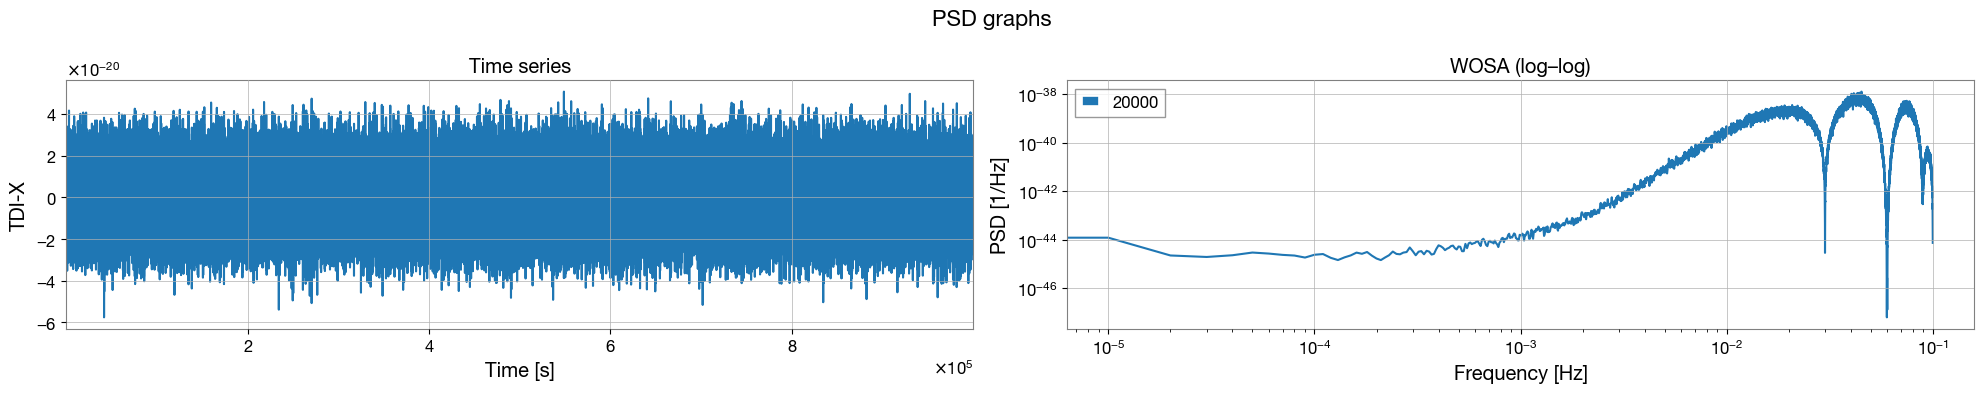

In [2]:
# 1) Read the TDI time series
tdi_path = getTdiPath('vsmall_glitch_long_tdi.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 20000
f_orig, orig_psd, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg
) 

# Plot the original psd for no reason 
# plot(data, t, fs, f_orig, orig_psd,  nperseg, title="TDI-X", bigtitle="PSD graphs")

# 3) generate n time-domain noise realisations such that PSD equals "PSD OF TDI time series "
time_noises = n_time_noise_from_psd(
    orig_psd, 
    fs, 
    nperseg, 
    n=1000,
    seed_offset=0
)

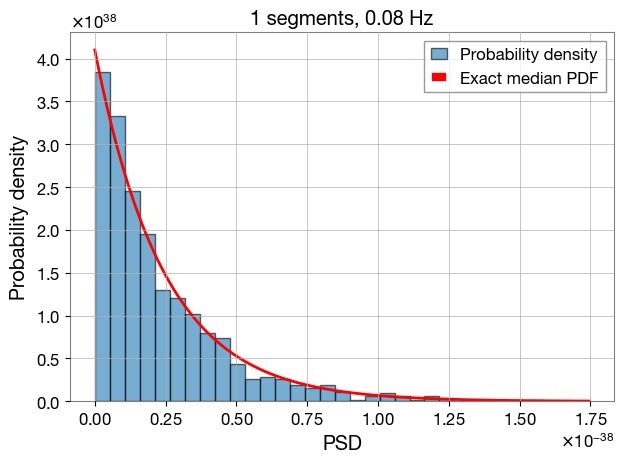

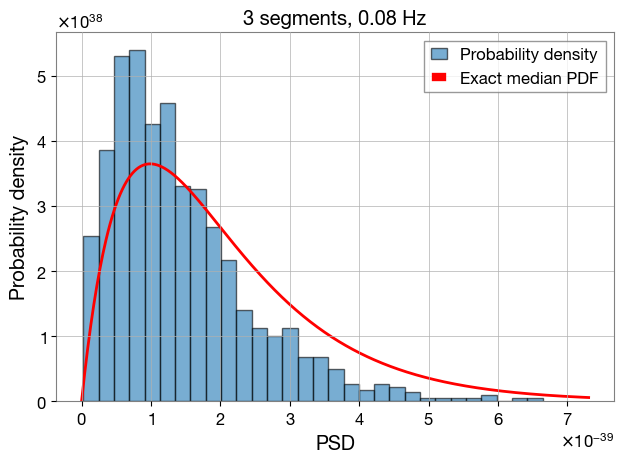

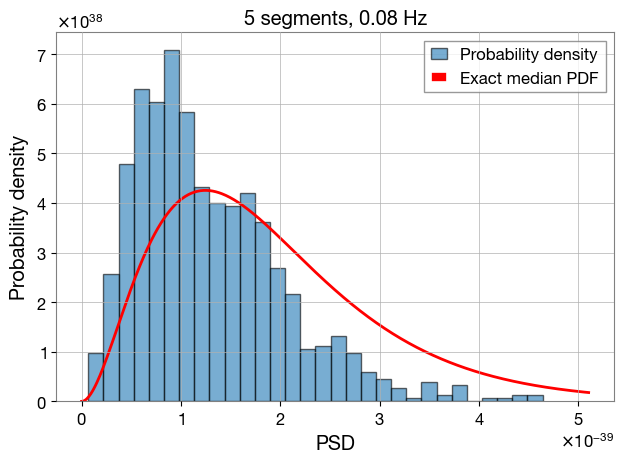

In [3]:
noverlap = 0
fraction = 0.8
nperseg_noise = 20000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

plot_median_histogram(psd_noise_vals,
                      nseg,              # N  – must be odd
                      orig_psd_val,      # scale parameter of Exp
                      title=f"{nseg} segments, {chosen_f_orig} Hz",
                      n_bins=30)

nperseg_noise = 6000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

plot_median_histogram(psd_noise_vals,
                      nseg,              # N  – must be odd
                      orig_psd_val,      # scale parameter of Exp
                      title=f"{nseg} segments, {chosen_f_orig} Hz",
                      n_bins=30)

nperseg_noise = 4000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

plot_median_histogram(psd_noise_vals,
                      nseg,              # N  – must be odd
                      orig_psd_val,      # scale parameter of Exp
                      title=f"{nseg} segments, {chosen_f_orig} Hz",
                      n_bins=30)

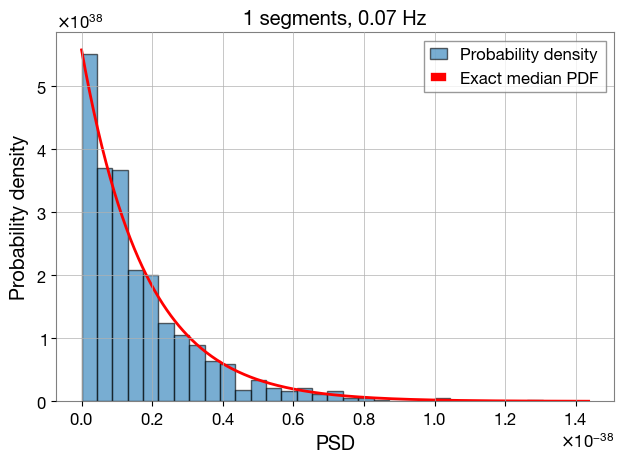

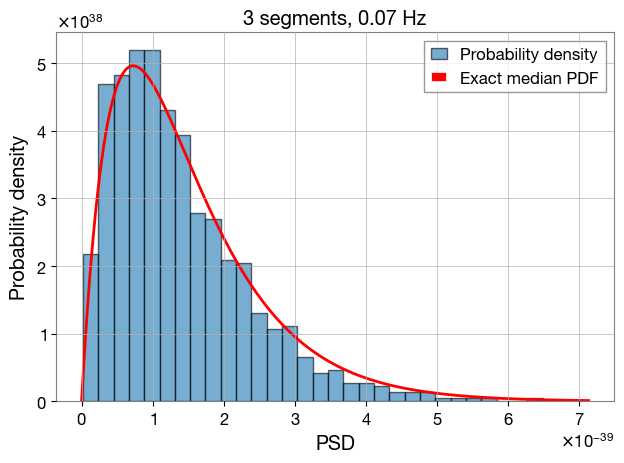

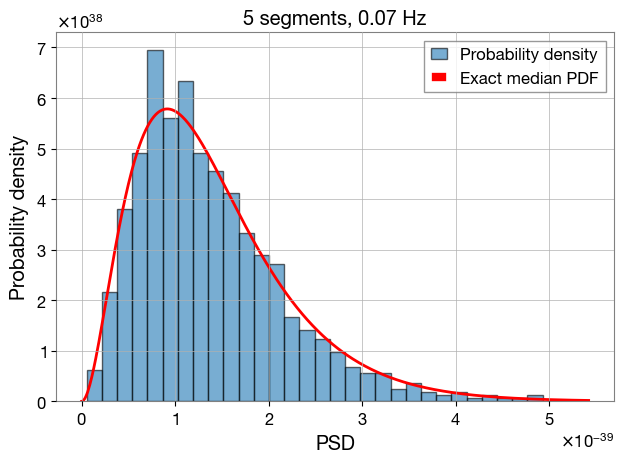

In [4]:
noverlap = 0
fraction = 0.7
nperseg_noise = 20000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

plot_median_histogram(psd_noise_vals,
                      nseg,              # N  – must be odd
                      orig_psd_val,      # scale parameter of Exp
                      title=f"{nseg} segments, {chosen_f_orig} Hz",
                      n_bins=30)

nperseg_noise = 6000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

plot_median_histogram(psd_noise_vals,
                      nseg,              # N  – must be odd
                      orig_psd_val,      # scale parameter of Exp
                      title=f"{nseg} segments, {chosen_f_orig} Hz",
                      n_bins=30)

nperseg_noise = 4000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

plot_median_histogram(psd_noise_vals,
                      nseg,              # N  – must be odd
                      orig_psd_val,      # scale parameter of Exp
                      title=f"{nseg} segments, {chosen_f_orig} Hz",
                      n_bins=30)

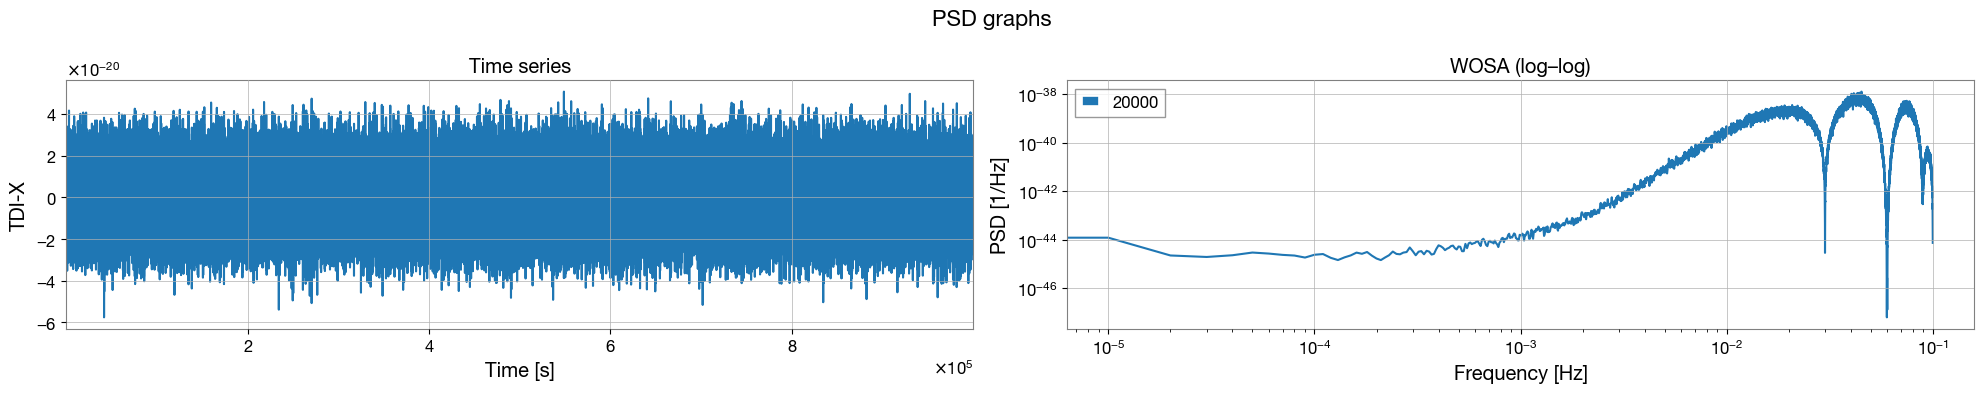

In [5]:
# 1) Read the TDI time series
tdi_path = getTdiPath('vsmall_glitch_long_tdi.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 20000
f_orig, orig_psd, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg
) 

# Plot the original psd for no reason 
# plot(data, t, fs, f_orig, orig_psd,  nperseg, title="TDI-X", bigtitle="PSD graphs")

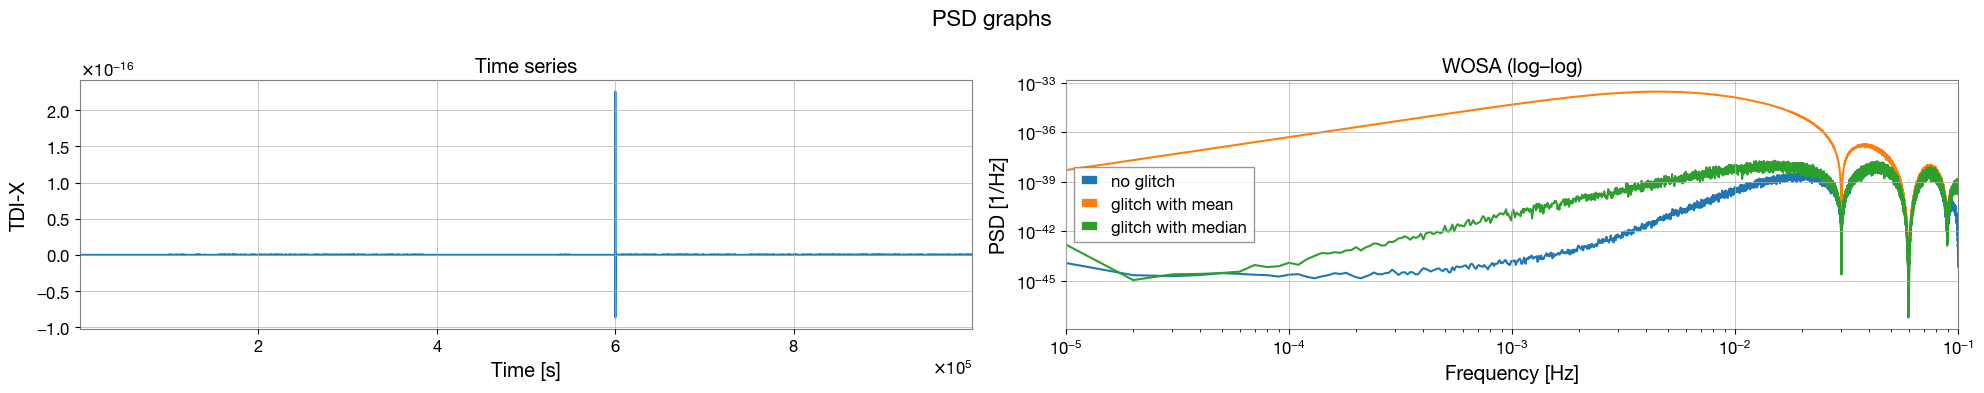

In [7]:
# 1) Read the TDI time series
tdi_path = getTdiPath('large_glitch_tdi.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 20000
f_orig, orig_psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_orig, orig_psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
# Plot the original psd for no reason 
plot(
    data=data,
    t=t, 
    fs=fs, 
    f=f_orig, 
    nper=nperseg, 
    psd= [orig_psd, orig_psd_mean, orig_psd_median],
    labels= ["no glitch", "glitch with mean", "glitch with median"],
    title="TDI-X", 
    bigtitle="PSD graphs"
)


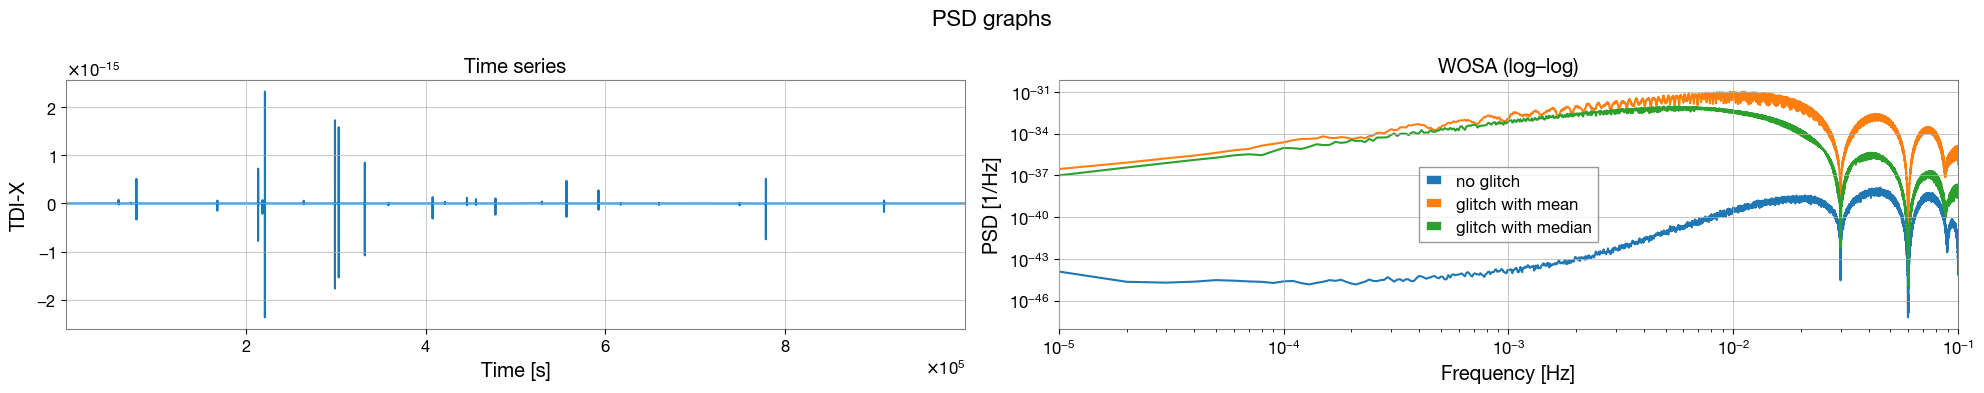

In [8]:

# 1) Read the TDI time series
tdi_path = getTdiPath('large_glitch_pos_tdi.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 20000
f_orig, orig_psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_orig, orig_psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
# Plot the original psd for no reason 
plot(
    data=data,
    t=t, 
    fs=fs, 
    f=f_orig, 
    nper=nperseg, 
    psd= [orig_psd, orig_psd_mean, orig_psd_median],
    labels= ["no glitch", "glitch with mean", "glitch with median"],
    title="TDI-X", 
    bigtitle="PSD graphs"
)


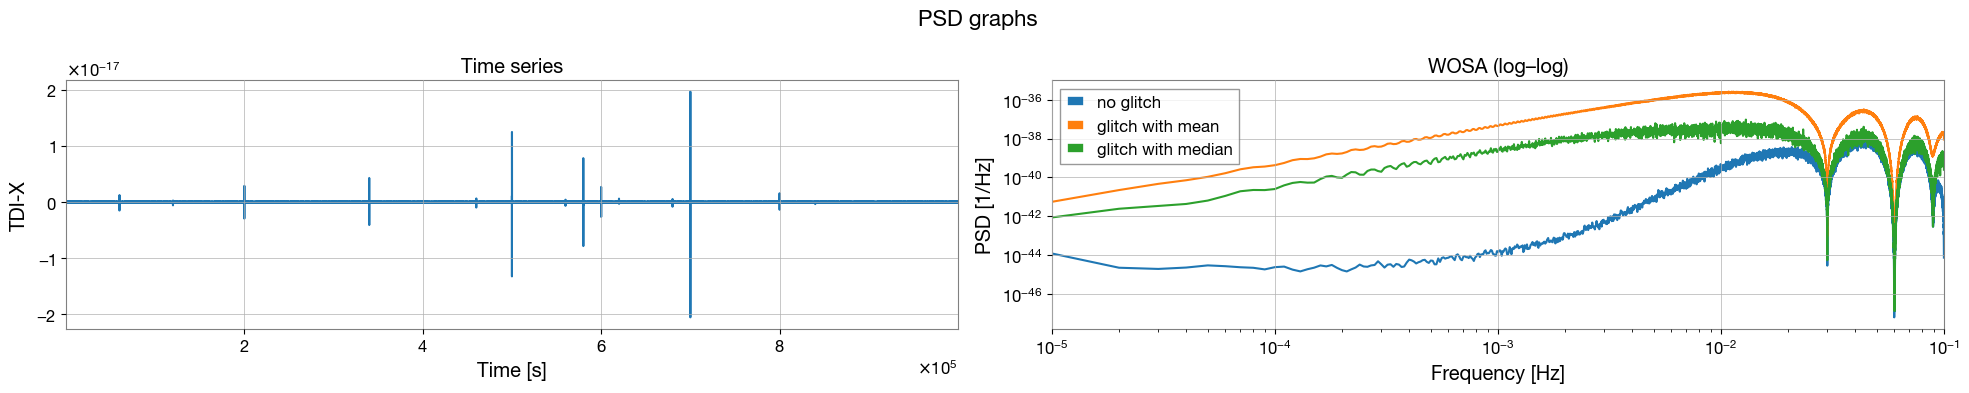

In [9]:

# 1) Read the TDI time series
tdi_path = getTdiPath('medium_glitch_tdi.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 20000
f_orig, orig_psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_orig, orig_psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
# Plot the original psd for no reason 
plot(
    data=data,
    t=t, 
    fs=fs, 
    f=f_orig, 
    nper=nperseg, 
    psd= [orig_psd, orig_psd_mean, orig_psd_median],
    labels= ["no glitch", "glitch with mean", "glitch with median"],
    title="TDI-X", 
    bigtitle="PSD graphs"
)

